# Assignment: Introduction to projective geometry

Miembros:  
* Juan Diego Perez Navarro - T00067699
* Jesus Miguel Pájaro García - T00068185

In [2]:
import os
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from PIL import Image

BASE_URL = "https://github.com/agmarrugo/computer-vision-utb/blob/main/data/{}?raw=true"


def download_data(filename: str, output_folder: str = "./data/") -> str:
    """
    Downloads a file found in BASE_URL specifying its filename
    
    Args:
        filename: The name of the file to download
        output_folder: The folder to store the downloaded file
        
    Returns:
        The path to the downloaded file
    """
    # Create the output directory if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    data_url = BASE_URL.format(filename)
    output_filename = os.path.join(output_folder, filename)

    # Download the file
    urllib.request.urlretrieve(data_url, output_filename)
    return output_filename

## Points in Homogeneous Coordinates

### Exercise 1
What is the 2D Cartesian coordinates of the points with homogeneous coordinates

\begin{align}
\mathbf{x_1} = \left(
\begin{array}{c}
4\\
-2\\
2\\
\end{array}
\right)
,\enspace
\mathbf{x_2} = \left(
\begin{array}{c}
3\\
-2\\
-1\\
\end{array}
\right)
, \enspace \text{and }
\mathbf{x_3} = \left(
\begin{array}{c}
4\lambda\\
-2\lambda\\
2\lambda\\
\end{array}
\right)
,\enspace
\lambda \neq 0?
\end{align}


What is the interpretation of the point with homogeneous coordinates

\begin{align}
\mathbf{x_4} = \left(
\begin{array}{c}
4\\
-2\\
0\\
\end{array}
\right)
\enspace?
\end{align}

### Respuesta

Para pasar de coordenadas homogeneas a cartesianas se hace de la siguiente manera:

$$
\mathbf{x_1} = \left(
\begin{array}{c}
\lambda_x  \\
\lambda_y \\
\lambda  \\
\end{array}
\right)

=

\left(
\begin{array}{c}
\lambda_x / \lambda  \\
\lambda_y / \lambda  \\
1  \\
\end{array}
\right)

\longrightarrow

\left(
\begin{array}{c}
\lambda_x / \lambda  \\
\lambda_y / \lambda  \\
\end{array}
\right)

$$

Siempre y cuando $\lambda \neq 0$. ¿Qué pasa cuando $\lambda = 0$? Es ese caso, lo que normalmente se hace es tomar las coordenadas cartesianas como $\infty$. Dependiendo al contexto, si se está trabajando con intersecciones de lineas, puede significar que no hay intersección o que hay infinitas.

### Computer Exercise 1.
Write a Python function `pflat` that divides the homogeneous coordinates with their last entry for points of any dimensionality. (You may assume that none of the points have last homogeneous coordinate zero.) Apply the function to the points in `x2D` and `x3D` in the file `compEx1.npz`, and plot the result.

In [3]:
filename = "compEx1.npz"
output_filename = download_data(filename)
data = np.load(output_filename)

x2D = data['x2D']
x3D = data['x3D']

Antes: (3, 63) --- Después: (2, 63)
Antes: (4, 441) --- Después: (3, 441)


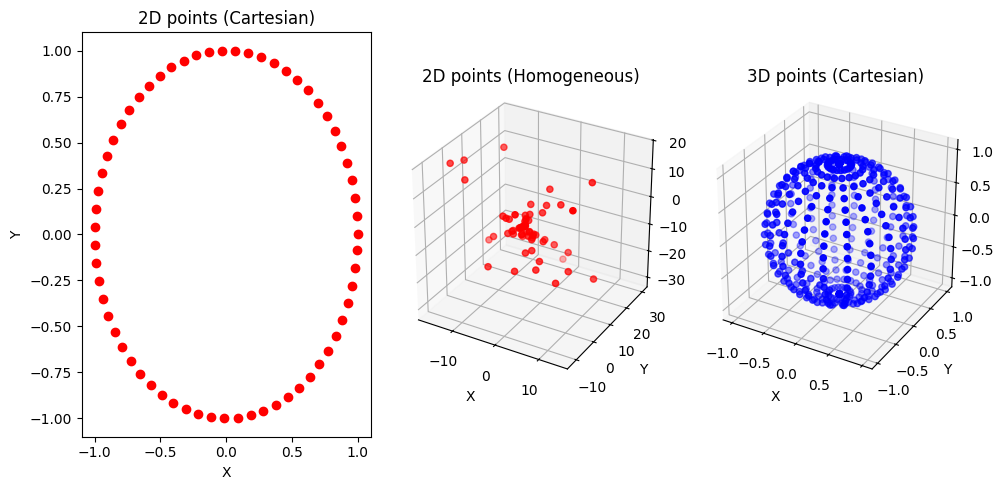

In [8]:
# Computer Exercise 1 - Solution.
def pflat(hx: np.ndarray) -> np.ndarray:
    """
    Normalizes array of homogeneous coordinates (2D or 3D) and converts
    to cartesian (inhomogeneous) coordinates.

    Args:
        hx: an N x npts array of homogeneous coordinates.
    Returns:
        x: an (N-1) x npts array of cartesian (inhomogeneous) coordinates
    """
    # Assuming that in the last row doesn't have any zeros
    return hx[:-1] / hx[-1]


# After defining the pflat function try it on the x2D and x3D points
x2Dn = pflat(x2D)
x3Dn = pflat(x3D)
print(f"Antes: {x2D.shape} --- Después: {x2Dn.shape}")
print(f"Antes: {x3D.shape} --- Después: {x3Dn.shape}")


fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(*x2Dn, c='r', marker='o')

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.scatter(*x2D, c='r', marker='o')

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(*x3Dn, c='b', marker='o')

titles = ["2D points (Cartesian)", "2D points (Homogeneous)", "3D points (Cartesian)"]
axes = [ax1, ax2, ax3]
for title, ax in (zip(titles, axes)):
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    try:
        ax.set_zlabel('Z')
        ax.set_box_aspect([1, 1, 1])
    except AttributeError:
        pass

fig.tight_layout()
plt.show()

### Exercise 2

**1.** Compute the homogeneous coordinates of the intersection (in $\mathbb{P}^2$) of the lines

\begin{align}
l_1 = \left(
\begin{array}{c}
1\\
1\\
1\\
\end{array}
\right)
, \enspace \text{and }
l_2 = \left(
\begin{array}{c}
3\\
2\\
1\\
\end{array}
\right)
.\enspace
\end{align}

What is the corresponding point in $\mathbb{R}^2$?

**2.** Compute the intersection (in $\mathbb{P}^2$) of the lines

\begin{align}
l_3 = \left(
\begin{array}{c}
1\\
2\\
3\\
\end{array}
\right)
, \enspace \text{and }
l_4 = \left(
\begin{array}{c}
1\\
2\\
1\\
\end{array}
\right)
.\enspace
\end{align}

What is the geometric interpretation in $\mathbb{R}^2$?

**3.** Compute the line that goes through the points with Cartesian coordinates

\begin{align}
x_1 = \left(
\begin{array}{c}
1\\
1\\
\end{array}
\right)
, \enspace \text{and }
x_2 = \left(
\begin{array}{c}
3\\
2\\
\end{array}
\right)
.\enspace
\end{align}

Hint: Re-use the calculations from the line intersections above.

### Respuesta

**1.** El resultado de la intersección entre 2 líneas es un punto cuando las líneas no son paralelas. Para encontrar dicho punto, se puede hacer un producto cruz entre ambas

$$
q_{12} = 
\left(
    \begin{array}{c}
        1 \\
        1 \\
        1 \\
    \end{array}
\right)

\times

\left(
    \begin{array}{c}
        3 \\
        2 \\
        1 \\
    \end{array}
\right)


=

\left|
    \begin{array}{c}
        \hat{\textbf{\i}} & \hat{\textbf{\j}} & \hat{\textbf{k}} \\
        1 & 1 & 1 \\
        3 & 2 & 1 \\
    \end{array}
\right|

=

\left(
    \begin{array}{c}
    -1 \\
    2 \\
    -1 \\
    \end{array}
\right)
$$

Así, para convertir el anterior punto de coordenadas homogeneas a cartesianas, basta con dividir entre $-1$ toda el vector. Luego, el punto resultante es:
$$
R_1 = \left(
    \begin{array}{c}
        1 \\
        -2 \\
    \end{array}
\right)
$$


**2.** Se harán los mismos pasos que se hizo en **1.**.
$$
q_{34} = 
\left(
    \begin{array}{c}
        1 \\
        2 \\
        3 \\
    \end{array}
\right)

\times

\left(
    \begin{array}{c}
        1 \\
        2 \\
        1 \\
    \end{array}
\right)


=

\left|
    \begin{array}{c}
        \hat{\textbf{\i}} & \hat{\textbf{\j}} & \hat{\textbf{k}} \\
        1 & 2 & 3 \\
        1 & 2 & 1 \\
    \end{array}
\right|

=

\left(
    \begin{array}{c}
    -1 \\
    2 \\
    0 \\
    \end{array}
\right)
$$

En este caso, el último elemento del vector es igual a 0, por lo que, no se puede convertir directamente a coordenadas cartesianas. ¿Tiene sentido que suceda esto? Sí. Las lineas usando coordenadas homogeneas representan a la ecuación: $\lambda_x x + \lambda_y y + \lambda = 0$. Entonces, para definir si dos rectas son paralelas basta con ver las primeras 2 componentes (en $x$ y $y$) y ver si son múltiplos una de la otra. En este caso, en $l_3$ y $l_4$ esas primeras dos componentes son iguales (múltiplos de 1), por tanto, sí son paralelas. La última componente solamente representa una traslación de la recta. En conclusión, las líneas nunca se intersecan, entonces, no es posible encontrar un punto en las coordenadas cartesianas (ver imagen en la siguiente celda).

**3.** Para encontrar una linea que interseque a dos puntos, nuevamente se hace un producto cruz entre ellos. Pero, antes de hacer la operación, los puntos que están en coordenadas cartesianas, se les debe convertir a homogeneas.

$$
x_1 = \left(
\begin{array}{c}
1 \\
1 \\
\end{array}
\right)

\longrightarrow

p_1 = \left(
\begin{array}{c}
1 \\
1 \\
1 \\
\end{array}
\right)

;\enspace

x_2 = \left(
\begin{array}{c}
3 \\
2 \\
\end{array}
\right)

\longrightarrow

p_2 = \left(
\begin{array}{c}
3 \\
2 \\
1 \\
\end{array}
\right)
$$



$$
l_5 =
\left(
\begin{array}{c}
1 \\
1 \\
1 \\
\end{array}
\right)

\times

\left(
\begin{array}{c}
3 \\
2 \\
1 \\
\end{array}
\right)
$$

Nótese que es el mismo cálculo que se hizo antes, pero en diferente contexto. Entonces
$$
l_5 =
\left(
\begin{array}{c}
-1 \\
2 \\
-1 \\
\end{array}
\right)

\longrightarrow

-x + 2y - 1 = 0
$$

La recta que pasa por los puntos es: $-x +2y = 1$

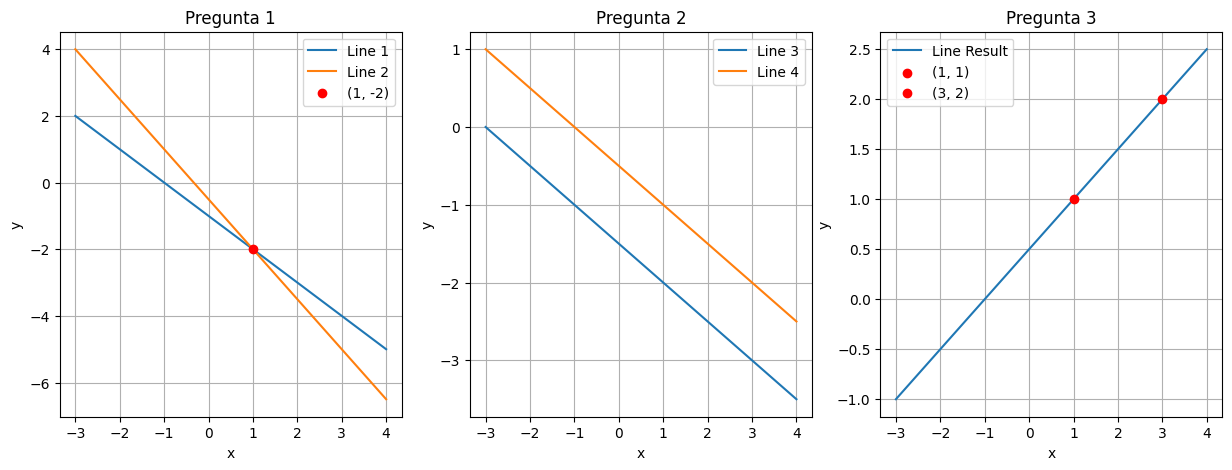

In [5]:
def line_equation(x: float, coef_x: float = 1, coef_y: float = 1, coef_c: float = 1) -> float:
    """
    Computes the y-coordinate of a line given the x-coordinate and the coefficients of the line equation.
    Line equation: coef_x * x + coef_y * y + coef_c = 0

    Args:
        x: The x-coordinate.
        coef_x: The coefficient of x in the line equation.
        coef_y: The coefficient of y in the line equation.
        coef_c: The constant term in the line equation.

    Returns:
        The y-coordinate corresponding to the given x-coordinate.
    """
    return (-coef_x * x - coef_c) / coef_y


X_MIN, X_MAX = -3, 4
dom = np.linspace(X_MIN, X_MAX, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Punto 1
coefs_line1 = (1, 1, 1)
coefs_line2 = (3, 2, 1)
answer_1 = (1, -2)

line1 = np.array([dom, line_equation(dom, *coefs_line1)])
line2 = np.array([dom, line_equation(dom, *coefs_line2)])

axes[0].plot(*line1, label='Line 1')
axes[0].plot(*line2, label='Line 2')
axes[0].scatter(*answer_1, c='r', zorder=10, marker='o', label='(1, -2)')
axes[0].set(xlabel='x', ylabel='y', title='Pregunta 1')

# Punto 2
coefs_line3 = (1, 2, 3)
coefs_line4 = (1, 2, 1)

line3 = np.array([dom, line_equation(dom, *coefs_line3)])
line4 = np.array([dom, line_equation(dom, *coefs_line4)])

axes[1].plot(*line3, label='Line 3')
axes[1].plot(*line4, label='Line 4')
axes[1].set(xlabel='x', ylabel='y', title='Pregunta 2')

# Punto 3
x1 = (1, 1)
x2 = (3, 2)
coefs_line_result = (-1, 2, -1)

line_result = np.array([dom, line_equation(dom, *coefs_line_result)])

axes[2].plot(*line_result, label='Line Result')
axes[2].scatter(*x1, c='r', zorder=10, marker='o', label=str(x1))
axes[2].scatter(*x2, c='r', zorder=10, marker='o', label=str(x2))
axes[2].set(xlabel='x', ylabel='y', title='Pregunta 3')

for ax in axes:
    ax.legend()
    ax.grid()

plt.show()

### Computer exercise 2

Load and plot the image in compEx2.jpg.

In the file `compEx2.npz` there are three pairs of image points. Plot the image points in the same figure as the image.

For each pair of points compute the line going through the points. Use the function `linePoints` to plot the lines in the same image. Do these lines appear to be parallel (in 3D)?

Compute the point of intersection between the second and third line (the lines obtained from the pairs `p2` and `p3`). Plot this point in the same image.

The distance between a 2D-point $x = (x_1, x_2)$ in Cartesian coordinates and a line $l = (a, b, c)$ can be computed using the distance formula

\begin{align}
d = \frac{|ax_1 + bx_2 + c|}{\sqrt{a^2+b^2}}
\end{align}

see your linear algebra book. Compute the distance between the first line and the the intersection point. Is it close to zero? Why/why not?

In [9]:
filename1 = "compEx2.npz"
filename2 = "compEx2.JPG"
output_filename1 = download_data(filename1)
output_filename2 = download_data(filename2)

data = np.load(output_filename1)

p1 = data["p1"]
p2 = data["p2"]
p3 = data["p3"]

print(f"{p1.shape = }")
print(f"{p2.shape = }")
print(f"{p3.shape = }")

p1.shape = (3, 2)
p2.shape = (3, 2)
p3.shape = (3, 2)


In [10]:
def linePoints(line = [0, 0, 0], ref = [-1.,1.]):
    """given a,b,c for straight line as ax+by+c=0,
    return and plot a pair of points based on ref values
    e.g linePoints(-1,1,2) == [[-1.0, -.0], [1.0, -1.0]]
    """
    a = line[0]
    b = line[1]
    c = line[2]
    if (a==0 and b==0):
      raise Exception("linePoints: a and b cannot both be zero")

    points = np.array([[-c/a, p] if b == 0 else [p, (-c - a*p) / b] for p in ref])
    plt.plot(points[:, 0], points[:, 1], 'ro')
    return points


def calc_distance(point: np.ndarray, line: np.ndarray) -> float:
    """
    Calculate the distance between a point and a line.

    Args:
        point: A 2D point represented as a numpy array.
        line: A 3D line represented as a numpy array.

    Returns:
        The distance between the point and the line.
    """
    numerator = np.abs(np.dot(line, np.append(point, 1)))  # |a*x0 + b*y0 + c|
    denominator = np.sqrt(np.sum(line[:2] ** 2))  # sqrt(a^2 + b^2)
    return numerator / denominator

Distance between x23 and lp1: 8.269491356256719


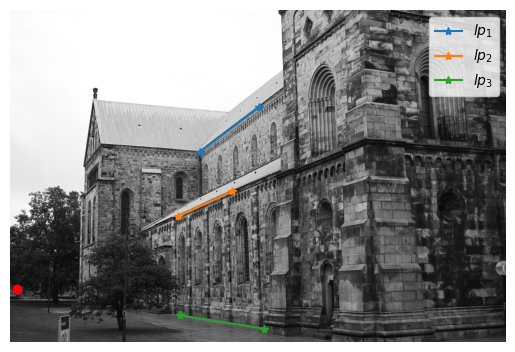

In [11]:
image = Image.open(output_filename2)

plt.imshow(image, cmap='gray')

lp1 = np.cross(p1[:, 0], p1[:, 1])
lp2 = np.cross(p2[:, 0], p2[:, 1])
lp3 = np.cross(p3[:, 0], p3[:, 1])

i = 0
for lp, p in zip((lp1, lp2, lp3), (p1, p2, p3)):
    i += 1
    plt.plot(p[0, :], p[1, :], marker="*", label=f"$lp_{i}$")

x23 = np.cross(lp2, lp3)
x23 = pflat(x23)
plt.plot(x23[0], x23[1], 'ro')

distance_x23 = calc_distance(x23, lp1)
print(f"Distance between x23 and lp1: {distance_x23}")

plt.axis('off')
plt.legend()
plt.show()

## Projective transformations

### Exercise 3   

Let $H$ be the projective transformation

\begin{align}
H =
\left(
\begin{array}{ccc}
1 & 1 & 0 \\
0 & 1 & 0 \\
-1 & 0 & 1 \\
\end{array}
\right) \enspace.
\end{align}

Compute the transformations $\mathbf{y_1} \sim H\mathbf{x_1}$ and $\mathbf{y_2} \sim H\mathbf{x_2}$ if

\begin{align}
\mathbf{x_1} = \left(
\begin{array}{c}
1\\
0\\
1\\
\end{array}
\right)
, \enspace \text{and }
\mathbf{x_2} = \left(
\begin{array}{c}
0\\
1\\
1\\
\end{array}
\right)
.\enspace
\end{align}

Compute the lines $l_1$, $l_2$ containing $\mathbf{x_1}$, $\mathbf{x_2}$, and $\mathbf{y_1}$, $\mathbf{y_2}$, respectively.

Compute $(H^{-1})^T l_1$ and compare to $l_2$.

### Respuesta

Lo primero que se debe hacer el calcular el producto matricial. Luego

$$
\mathbf{y_1} \sim
\left(
    \begin{array}{ccc}
    1 & 1 & 0 \\
    0 & 1 & 0 \\
    -1 & 0 & 1 \\
    \end{array}
\right)

\left(
    \begin{array}{c}
    1 \\
    0 \\
    1 \\
    \end{array}
\right)

=

\left(
    \begin{array}{c}
    1 \\
    0 \\
    0 \\
    \end{array}
\right)
$$

$$
\mathbf{y_2} \sim
\left(
    \begin{array}{ccc}
    1 & 1 & 0 \\
    0 & 1 & 0 \\
    -1 & 0 & 1 \\
    \end{array}
\right)

\left(
    \begin{array}{c}
    0 \\
    1 \\
    1 \\
    \end{array}
\right)

=

\left(
    \begin{array}{c}
    1 \\
    1 \\
    1 \\
    \end{array}
\right)
$$

Ahora, es necesario buscar las rectas que contengan $\mathbf{x_1}$, $\mathbf{x_2}$ ($l_1$), y $\mathbf{y_1}$, $\mathbf{y_2}$ ($l_2$). Para ello, se realizará el producto cruz entre cada par.

$$
l_1 = \mathbf{x_1} \times \mathbf{x_2} =
\left(
    \begin{array}{c}
    -1 \\
    -1 \\
    1 \\
    \end{array}
\right)
$$

$$
l_2 = \mathbf{y_1} \times \mathbf{y_2} =
\left(
    \begin{array}{c}
    0 \\
    -1 \\
    1 \\
    \end{array}
\right)
$$

Ahora, calcular $\left( H^{-1} \right)^T l_1$, para luego comparar con $l_2$.

$$
H^{-1} =
\left(
    \begin{array}{ccc}
    1 & 1 & 0 \\
    0 & 1 & 0 \\
    -1 & 0 & 1 \\
    \end{array}
\right)^{-1} =
\left(
    \begin{array}{ccc}
    1 & -1 & 0 \\
    0 & 1 & 0 \\
    1 & -1 & 1 \\
    \end{array}
\right)

\longrightarrow

\left( H^{-1} \right)^T =
\left(
    \begin{array}{ccc}
    1 & -1 & 0 \\
    0 & 1 & 0 \\
    1 & -1 & 1 \\
    \end{array}
\right)^{T} =
\left(
    \begin{array}{ccc}
    1 & 0 & 1 \\
    -1 & 1 & -1 \\
    0 & 0 & 1 \\
    \end{array}
\right)
$$

$$
\left( H^{-1} \right)^T l_1 =
\left(
    \begin{array}{ccc}
    1 & 0 & 1 \\
    -1 & 1 & -1 \\
    0 & 0 & 1 \\
    \end{array}
\right)
\left(
    \begin{array}{c}
    -1 \\
    -1 \\
    1 \\
    \end{array}
\right)

=

\left(
    \begin{array}{c}
    0 \\
    -1 \\
    1 \\
    \end{array}
\right)
$$

Así, $l_2$ es igual a $\left( H^{-1} \right)^{T} l_1$

In [91]:
H = np.array([
    [1, 1, 0],
    [0, 1, 0],
    [-1, 0, 1]
])

H_inv = np.linalg.inv(H)
display(H_inv, H_inv.T)

array([[ 1., -1.,  0.],
       [ 0.,  1.,  0.],
       [ 1., -1.,  1.]])

array([[ 1.,  0.,  1.],
       [-1.,  1., -1.],
       [ 0.,  0.,  1.]])

### Computer Exercise 3

The file `compEx3.npz` contains the start and end points of a set of lines. Plotting the lines gives the grid shown in the figure below.

For each of the projective mappings given by the matrices

\begin{align}
H_1 =
\left(
\begin{array}{ccc}
\sqrt{3} & -1 & 1 \\
1 & \sqrt{3} & 1 \\
0 & 0 & 2 \\
\end{array}
\right), \enspace \text{and }
H_2 =
\left(
\begin{array}{ccc}
1 & -1 & 1 \\
1 & 1 & 0 \\
0 & 0 & 1 \\
\end{array}
\right)
\enspace,
\end{align}

\begin{align}
H_3 =
\left(
\begin{array}{ccc}
1 & 1 & 0 \\
0 & 2 & 0 \\
0 & 0 & 1 \\
\end{array}
\right), \enspace \text{and }
H_4 =
\left(
\begin{array}{ccc}
\sqrt{3} & -1 & 1 \\
1 & \sqrt{3} & 1 \\
1/4 & 1/2 & 2 \\
\end{array}
\right)
\enspace,
\end{align}

compute the transformations of the given start and endpoints and plot the lines between them. (Note that you do not need to loop over the points. One matrix multiplication for the start and end points is enough. To compute cartesian coordinates you can use your `pflat` function. Don’t forget to use the `plt.axis('equal')` command, otherwise the figures might look distorted.)

Which of the transformations preserve lengths between points? Which preserve angles between lines? Which maps parallel lines to parallel lines? Classify the transformations into euclidean, similarity, affine and projective transformations.

In [106]:
def plot_ex3(startpoints: np.ndarray, endpoints: np.ndarray, is_homogeneous: bool = False, ax = None) -> None:
    if is_homogeneous:
        startpoints = pflat(startpoints)
        endpoints = pflat(endpoints)
    if ax is None:
        _, ax = plt.subplots()
    ax.plot([startpoints[0, :], endpoints[0, :]], [startpoints[1, :], endpoints[1, :]], 'b-')
    ax.axis('equal')

startpoints.shape = (2, 42)
endpoints.shape = (2, 42)
startpoints_h.shape = (3, 42)
endpoints_h.shape = (3, 42)


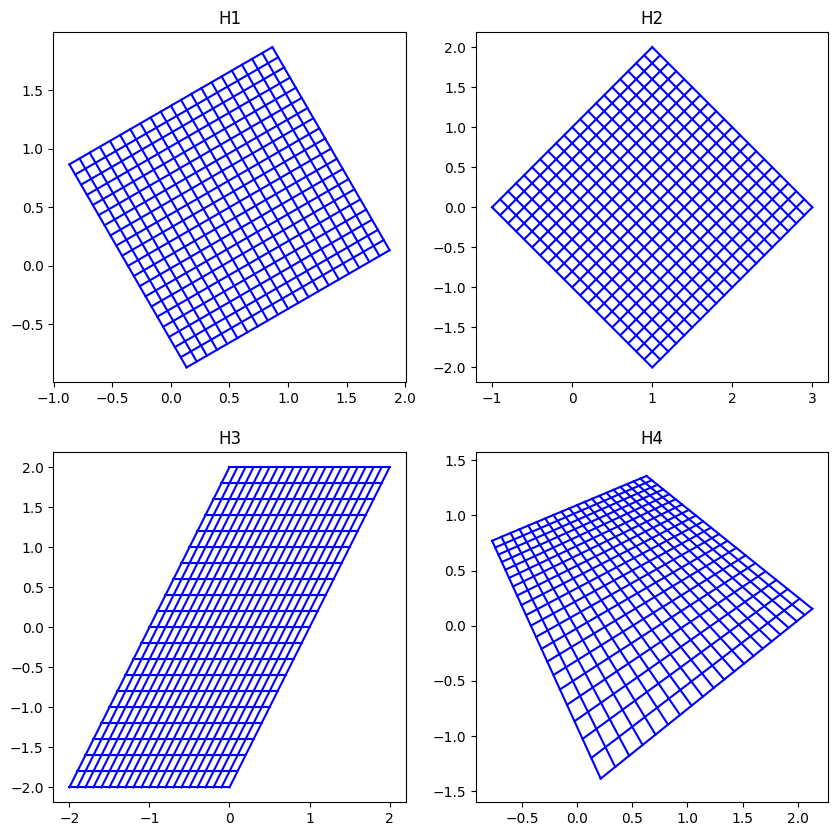

In [108]:
filename = "compEx3.npz"
output_filename = download_data(filename)
data = np.load(output_filename)

startpoints = data["startpoints"]
endpoints = data["endpoints"]

print(f"{startpoints.shape = }")
print(f"{endpoints.shape = }")

H1 = np.array([[np.sqrt(3), -1, 1], [1, np.sqrt(3), 1], [0, 0, 2]])
H2 = np.array([[1, -1, 1], [1, 1, 0], [0, 0, 1]])
H3 = np.array([[1, 1, 0], [0, 2, 0], [0, 0, 1]])
H4 = np.array([[np.sqrt(3), -1, 1], [1, np.sqrt(3), 1], [1/4, 1/2, 2]])

startpoints_h = np.vstack((startpoints, np.ones(startpoints.shape[1])))
endpoints_h = np.vstack((endpoints, np.ones(endpoints.shape[1])))

print(f"{startpoints_h.shape = }")
print(f"{endpoints_h.shape = }")

HS1, HE1 = H1 @ startpoints_h, H1 @ endpoints_h
HS2, HE2 = H2 @ startpoints_h, H2 @ endpoints_h
HS3, HE3 = H3 @ startpoints_h, H3 @ endpoints_h
HS4, HE4 = H4 @ startpoints_h, H4 @ endpoints_h

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
plot_ex3(HS1, HE1, True, axes[0, 0])
axes[0, 0].set_title("H1")
plot_ex3(HS2, HE2, True, axes[0, 1])
axes[0, 1].set_title("H2")
plot_ex3(HS3, HE3, True, axes[1, 0])
axes[1, 0].set_title("H3")
plot_ex3(HS4, HE4, True, axes[1, 1])
axes[1, 1].set_title("H4")
plt.show()


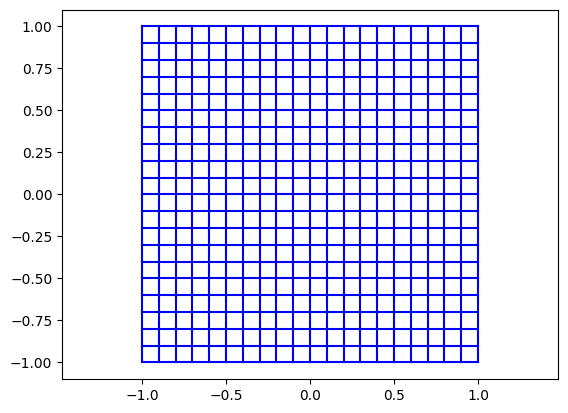

In [105]:
plt.plot([startpoints[0, :], endpoints[0, :]], [startpoints[1, :], endpoints[1, :]], 'b-')
plt.axis('equal')
plt.show()


* Euclidean transformation: H1. Se preservan los angulos y longitudes
* Similarity transformation: H2. Hay escalamiento
* Affine transformation: H3. Conserva el paralelismo entre las líneas rectas y la última fila es 0, 0, 1. Eso quiere decir que la matriz de transformación nace de una matriz nxn, donde n es la dimensión cartesiana.
* Projective transformation: H4. Aquí la última fila de la matriz de transformación no es 0, 0, 1.